In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [21]:
data = {
    'student id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'marks': [95, 98, 92, 10000, 91, 89, 90, 2000, 100, 100]
}

df = pd.DataFrame(data)

In [22]:
df

,student id,marks
0,1,95
1,2,98
2,3,92
3,4,10000
4,5,91
5,6,89
6,7,90
7,8,2000
8,9,100
9,10,100


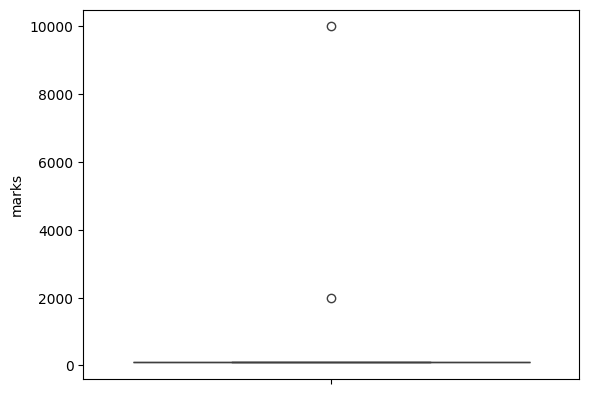

In [23]:
sns.boxplot(df.marks)
plt.show()

In [27]:
random_state = np.random.RandomState(42)
print(random_state)
model=IsolationForest(n_estimators=100,max_samples='auto',contamination=float(0.2),random_state=random_state)

model.fit(df[['marks']])

print(model.get_params())

RandomState(MT19937)
{'bootstrap': False, 'contamination': 0.2, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': RandomState(MT19937) at 0x1788FA25240, 'verbose': 0, 'warm_start': False}


In [32]:
df['scores'] = model.decision_function(df[['marks']])

df['anomaly_score'] = model.predict(df[['marks']])

# df[df['anomaly_score']==-1].head()
df[df['anomaly_score'] != 0]


,student id,marks,scores,anomaly_score
0,1,95,0.066074,1
1,2,98,0.052864,1
2,3,92,0.098415,1
3,4,10000,-0.318638,-1
4,5,91,0.106519,1
5,6,89,0.054518,1
6,7,90,0.098212,1
7,8,2000,-0.211458,-1
8,9,100,0.069109,1
9,10,100,0.069109,1


In [20]:
anomaly_count=2
accuracy = 100*list(df['anomaly_score']).count(-1)/(anomaly_count)
print("Accuracy of the model:", accuracy)

Accuracy of the model: 100.0


In [19]:
data = pd.read_csv('NYC_taxi_fare_data.csv')
data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.00,3.00,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.00,3.00,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.00,3.00,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.50,0.50,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.50,0.50,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6405003,NaN,2020-01-31 22:51:00,2020-01-31 23:22:00,NaN,3.24,NaN,NaN,237,234,NaN,17.59,2.75,0.5,0.00,0.00,0.3,21.14,0.0
6405004,NaN,2020-01-31 22:10:00,2020-01-31 23:26:00,NaN,22.13,NaN,NaN,259,45,NaN,46.67,2.75,0.5,0.00,12.24,0.3,62.46,0.0
6405005,NaN,2020-01-31 22:50:07,2020-01-31 23:17:57,NaN,10.51,NaN,NaN,137,169,NaN,48.85,2.75,0.0,0.00,0.00,0.3,51.90,0.0
6405006,NaN,2020-01-31 22:25:53,2020-01-31 22:48:32,NaN,5.49,NaN,NaN,50,42,NaN,27.17,2.75,0.0,0.00,0.00,0.3,30.22,0.0


In [ ]:
random_state = np.random.RandomState(41)
print(random_state)
model=IsolationForest(n_estimators=100, max_samples='auto', contamination=float(0.2), random_state=random_state)

model.fit(data[['marks']])

print(model.get_params())